# RF Signal Anomaly Detection using Deep Autoencoders

## Project Theme

This project detects abnormal RF communication signals using a **Deep Autoencoder**.

The model is trained only on **normal RF signal behavior**.  
During testing, if a signal produces high reconstruction error, it is classified as an **anomaly**.

---

## Main Idea

Normal RF Signal → Autoencoder reconstructs well → Low reconstruction error → Normal

Jammed / Abnormal RF Signal → Autoencoder reconstructs poorly → High reconstruction error → Anomaly

## 1. Background

RF signals, or Radio Frequency signals, are electromagnetic waves used for wireless communication.

They are used in:

- Mobile communication
- Wi-Fi and Bluetooth
- GPS and satellite communication
- Radar systems
- Defence communication
- Surveillance systems
- IoT wireless devices

In a defence-inspired communication scenario, RF signals must be reliable and secure.  
However, RF signals can be affected by jamming, interference, or abnormal noise.

Such abnormal signals can disturb communication quality and may indicate security issues.

Therefore, detecting abnormal RF signal behavior is important.

## 2. Problem Statement

RF communication signals can be affected by jamming, interference, or abnormal noise.  
These abnormal signals can disturb communication quality and may indicate security issues in wireless communication systems.

The objective of this project is to detect abnormal RF signals using a Deep Autoencoder.

The model is trained only on normal RF signal behavior, and anomalies are detected using reconstruction error.

## 3. Objective

The main objective of this project is to detect abnormal RF signals using a Deep Autoencoder.

### Specific Objectives

1. Load and understand the RF signal dataset.
2. Select normal RF signals from the dataset.
3. Preprocess the RF signals for model training.
4. Train a Deep Autoencoder only on normal signals.
5. Simulate jammed RF signals by adding strong random noise.
6. Calculate reconstruction error.
7. Classify signals as normal or anomaly using a threshold.
8. Evaluate the model using accuracy, confusion matrix, and classification report.

## 4. Introduction to Autoencoders

An Autoencoder is a neural network that learns to reconstruct its input.

It has two main parts:

### Encoder

The encoder compresses the input data into a smaller representation.

### Decoder

The decoder reconstructs the original input from the compressed representation.

### Flow

Input → Encoder → Compressed Representation → Decoder → Reconstructed Output

The compression step forces the model to learn the important pattern of the data instead of simply copying everything.

In this project, the Autoencoder learns the pattern of normal RF signals.

## 5. Why Autoencoder is Used for Anomaly Detection

In many real-world anomaly detection problems, we may not have examples of all possible abnormal situations.

For example, in RF communication:

- Different jamming patterns may exist.
- Interference may change over time.
- Abnormal signals may be rare.
- Real attack data may not be available.

A normal supervised classifier needs both normal and anomaly examples.

But an Autoencoder can be trained only on normal data.

After training:

- Normal signals are reconstructed well.
- Abnormal signals are not reconstructed well.
- Reconstruction error becomes high for anomalies.

This makes Autoencoder suitable for anomaly detection.

## 6. Reconstruction Error

Reconstruction error measures how different the original input and reconstructed output are.

In this project, Mean Squared Error is used.

### Formula

MSE = mean((Original Signal - Reconstructed Signal)²)

If reconstruction error is low, the signal is considered normal.  
If reconstruction error is high, the signal is considered anomalous.

## 7. Import Required Libraries

In this section, we import all libraries required for:

- File handling
- Data loading
- Data preprocessing
- Model building
- Training
- Evaluation
- Visualization

In [1]:
# -------------------------------
# Import required libraries
# -------------------------------

# File handling
import os
import glob
import pickle

# Numerical operations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.21.0


## 8. Locate the Dataset File

The dataset used is **RadioML 2016.10A**.

Expected dataset file name:

`RML2016.10a_dict.dat`

Keep this file in the same folder as this notebook.

This cell checks whether the dataset file is available.  
If it is not found directly, it searches inside subfolders.

In [2]:
# -------------------------------
# Locate dataset file
# -------------------------------

# Expected dataset filename
expected_file = "RML2016.10a_dict.dat"

# First check in the current folder
if os.path.exists(expected_file):
    dataset_path = expected_file
else:
    # Search inside subfolders if not found in current folder
    matching_files = glob.glob("**/RML2016.10a_dict.dat", recursive=True)

    if len(matching_files) > 0:
        dataset_path = matching_files[0]
    else:
        dataset_path = None

# Display result
if dataset_path is None:
    print("Dataset file not found.")
    print("Please place RML2016.10a_dict.dat in the same folder as this notebook.")
else:
    print("Dataset file found:", dataset_path)
    file_size_mb = os.path.getsize(dataset_path) / (1024 * 1024)
    print("File size:", round(file_size_mb, 2), "MB")

Dataset file found: RML2016.10a_dict.dat
File size: 613.31 MB


## 9. Load the RF Dataset

The dataset is stored in Python pickle format.

After loading, the dataset becomes a Python dictionary.

### Dictionary Structure

Each key is:

`(modulation_type, SNR_value)`

Example:

`('QPSK', 10)`

Each value contains RF signal samples with shape:

`(1000, 2, 128)`

Where:

- 1000 = number of samples
- 2 = I and Q components
- 128 = signal/time samples

In [3]:
# -------------------------------
# Load dataset using pickle
# -------------------------------

if dataset_path is None:
    raise FileNotFoundError("Dataset file is missing. Please add RML2016.10a_dict.dat and run again.")

# Load the dataset
with open(dataset_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Dataset loaded successfully.")
print("Type of dataset:", type(data))
print("Total number of keys:", len(data))

# Show first few keys
print("\nFirst 5 keys:")
for key in list(data.keys())[:5]:
    print(key, "->", data[key].shape)

Dataset loaded successfully.
Type of dataset: <class 'dict'>
Total number of keys: 220

First 5 keys:
('QPSK', 2) -> (1000, 2, 128)
('PAM4', 8) -> (1000, 2, 128)
('AM-DSB', -4) -> (1000, 2, 128)
('GFSK', 6) -> (1000, 2, 128)
('QAM64', 8) -> (1000, 2, 128)


## 10. Understand Dataset Modulations and SNR Values

The dataset contains different modulation types and SNR values.

### Modulation

Modulation is the process of changing a carrier signal so that it can carry information.

Examples:

- BPSK
- QPSK
- QAM16
- QAM64
- AM-DSB
- WBFM

### SNR

SNR means Signal-to-Noise Ratio.

- High SNR = cleaner signal
- Low SNR = noisy signal

In this project, high SNR values are selected to represent cleaner normal RF signals.

In [4]:
# -------------------------------
# Extract modulation types and SNR values
# -------------------------------

# Extract unique modulation names from dataset keys
modulations = sorted(list(set([key[0] for key in data.keys()])))

# Extract unique SNR values from dataset keys
snr_values = sorted(list(set([key[1] for key in data.keys()])))

print("Available modulation types:")
print(modulations)

print("\nAvailable SNR values:")
print(snr_values)

print("\nNumber of modulation types:", len(modulations))
print("Number of SNR values:", len(snr_values))

Available modulation types:
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']

Available SNR values:
[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

Number of modulation types: 11
Number of SNR values: 20


## 11. Select Normal RF Signals

For this project, **QPSK** signals are selected as normal RF signals.

Selected SNR values:

`10, 12, 14, 16, 18`

These are high SNR values, so the signals are cleaner.

Each SNR group contains 1000 samples.

Therefore:

5 SNR values × 1000 samples = 5000 normal samples

### Important

In this notebook, anomaly signals are not taken as a separate modulation class.  
Instead, jammed anomaly signals are simulated by adding strong random noise to normal RF signals.

In [5]:
# -------------------------------
# Select normal RF signals
# -------------------------------

# Normal modulation selected for this project
normal_modulation = "QPSK"

# High SNR values selected for cleaner signals
selected_snrs = [10, 12, 14, 16, 18]

# List to store selected normal signals
normal_signals = []

# Collect QPSK signals for selected SNR values
for snr in selected_snrs:
    key = (normal_modulation, snr)

    if key in data:
        normal_signals.append(data[key])
        print("Added:", key, "Shape:", data[key].shape)
    else:
        print("Missing:", key)

# Combine all selected signals into one NumPy array
normal_signals = np.vstack(normal_signals)

print("\nFinal normal signals shape:", normal_signals.shape)

Added: ('QPSK', 10) Shape: (1000, 2, 128)
Added: ('QPSK', 12) Shape: (1000, 2, 128)
Added: ('QPSK', 14) Shape: (1000, 2, 128)
Added: ('QPSK', 16) Shape: (1000, 2, 128)
Added: ('QPSK', 18) Shape: (1000, 2, 128)

Final normal signals shape: (5000, 2, 128)


## 12. Visualize One RF Signal

Each RF signal contains two components:

- I component
- Q component

These are commonly used to represent RF signals digitally.

The signal shape is:

`2 × 128`

This cell plots one sample RF signal to understand the data visually.

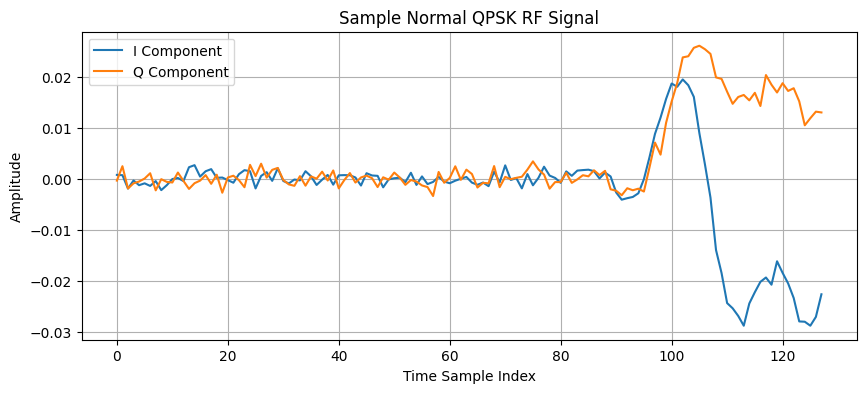

Sample signal shape: (2, 128)


In [6]:
# -------------------------------
# Visualize one normal RF signal
# -------------------------------

# Select one sample signal
sample_signal = normal_signals[0]

# Plot I and Q components
plt.figure(figsize=(10, 4))

plt.plot(sample_signal[0], label="I Component")
plt.plot(sample_signal[1], label="Q Component")

plt.title("Sample Normal QPSK RF Signal")
plt.xlabel("Time Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

print("Sample signal shape:", sample_signal.shape)

## 13. Flatten the RF Signals

The original RF signal shape is:

`(samples, 2, 128)`

For a Dense Autoencoder, each input should be a one-dimensional feature vector.

So each signal is flattened:

`2 × 128 = 256 features`

After flattening:

`(5000, 2, 128)` becomes `(5000, 256)`

In [7]:
# -------------------------------
# Flatten RF signals
# -------------------------------

# Number of samples
num_samples = normal_signals.shape[0]

# Flatten 2 x 128 into 256 features
X_normal = normal_signals.reshape(num_samples, -1)

print("Original shape:", normal_signals.shape)
print("Flattened shape:", X_normal.shape)
print("Number of features per signal:", X_normal.shape[1])

Original shape: (5000, 2, 128)
Flattened shape: (5000, 256)
Number of features per signal: 256


## 14. Normalize the Data

Normalization helps the neural network train better.

Here, all values are divided by the maximum absolute value found in normal data.

This keeps values in a smaller range.

### Why normalization is important?

Without normalization, large input values can make training unstable.  
Normalization helps the model learn faster and more smoothly.

In [8]:
# -------------------------------
# Normalize data
# -------------------------------

# Find maximum absolute value from normal signals
max_value = np.max(np.abs(X_normal))

# Normalize normal signals
X_normal = X_normal / max_value

print("Maximum absolute value used for normalization:", max_value)
print("Minimum value after normalization:", np.min(X_normal))
print("Maximum value after normalization:", np.max(X_normal))

Maximum absolute value used for normalization: 0.0926718
Minimum value after normalization: -0.86578846
Maximum value after normalization: 1.0


## 15. Train-Test Split

The Autoencoder is trained only on normal RF signals.

We split normal data into:

- Training data: used to train the model
- Testing data: used to check reconstruction error for normal signals

The model will never see jammed signals during training.

In [9]:
# -------------------------------
# Split normal data into train and test sets
# -------------------------------

X_normal_train, X_normal_test = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Normal training data shape:", X_normal_train.shape)
print("Normal testing data shape:", X_normal_test.shape)

Normal training data shape: (4000, 256)
Normal testing data shape: (1000, 256)


## 16. Build the Deep Autoencoder

The Autoencoder architecture used here is a Dense Autoencoder.

### Input

256 RF signal features

### Encoder

The encoder compresses the signal:

256 → 64 → 32

### Bottleneck

The compressed representation has 32 features.

### Decoder

The decoder reconstructs the signal:

32 → 64 → 256

### Output

The reconstructed RF signal has 256 features.

The model is trained to make the output close to the input.

In [10]:
# -------------------------------
# Build Deep Autoencoder model
# -------------------------------

# Clear previous TensorFlow session
tf.keras.backend.clear_session()

# Input dimension = number of features in each RF signal
input_dim = X_normal_train.shape[1]

# Bottleneck/compressed representation dimension
encoding_dim = 32

# Input layer
input_layer = Input(shape=(input_dim,), name="input_layer")

# Encoder part
encoded = Dense(64, activation="relu", name="encoder_dense_1")(input_layer)
encoded = Dense(32, activation="relu", name="encoder_dense_2")(encoded)

# Bottleneck layer
bottleneck = Dense(encoding_dim, activation="relu", name="compressed_layer")(encoded)

# Decoder part
decoded = Dense(32, activation="relu", name="decoder_dense_1")(bottleneck)
decoded = Dense(64, activation="relu", name="decoder_dense_2")(decoded)

# Output layer
# Linear activation is used because this is a reconstruction problem
output_layer = Dense(input_dim, activation="linear", name="reconstructed_output")(decoded)

# Create model
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="RF_Anomaly_Autoencoder")

# Compile model
autoencoder.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)

# Display model architecture
autoencoder.summary()

Model: "RF_Anomaly_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_1 (Dense)              │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_2 (Dense)              │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ compressed_layer (Dense)             │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense_1 (Dense)              │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense_2 (Dense)              │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstructed_output (Dense)         │ (None, 256)                 │          16,640 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,392 (153.88 KB)

 Trainable params: 39,392 (153.88 KB)

 Non-trainable params: 0 (0.00 B)

## 17. Train the Autoencoder

The Autoencoder is trained like this:

Input = Normal RF signal  
Output = Same normal RF signal

So the model learns to reconstruct normal RF signals.

### EarlyStopping

EarlyStopping stops training when validation loss does not improve for a few epochs.  
This prevents unnecessary training and reduces overfitting.

In [11]:
# -------------------------------
# Train the Autoencoder only on normal signals
# -------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_normal_train,
    X_normal_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_normal_test, X_normal_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

## 18. Plot Training Loss

The training loss graph shows how well the Autoencoder is learning.

- Training loss: reconstruction error on training data
- Validation loss: reconstruction error on test normal data

If both losses decrease and remain close, the model is learning properly.

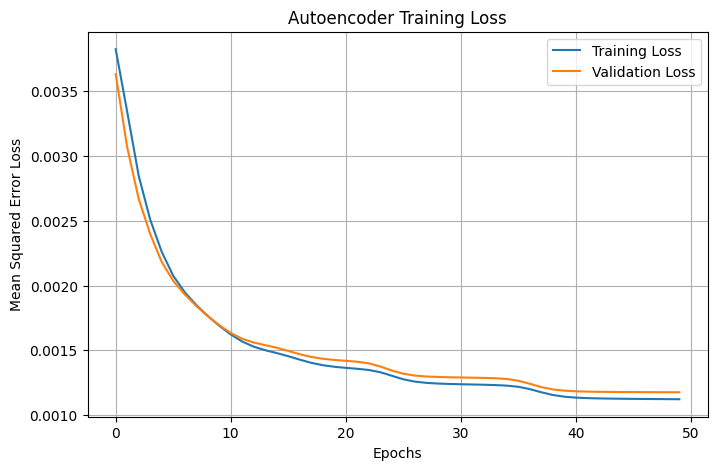

In [12]:
# -------------------------------
# Plot training and validation loss
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## 19. Create Simulated Jammed RF Signals

In this project, real defence jamming data is not used.

Instead, jamming is simulated by adding strong random noise to normal RF signals.

This represents abnormal RF behavior such as:

- Jamming
- Interference
- Abnormal noise

### Important

The anomaly signal is simulated for experimental purposes.

In [13]:
# -------------------------------
# Create simulated jammed anomaly signals
# -------------------------------

# Noise strength
jamming_noise_factor = 0.8

# Create random noise with the same shape as normal test data
jamming_noise = jamming_noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_normal_test.shape
)

# Add noise to normal signals to create jammed anomaly signals
X_jammed_anomaly = X_normal_test + jamming_noise

print("Normal test data shape:", X_normal_test.shape)
print("Jammed anomaly data shape:", X_jammed_anomaly.shape)

Normal test data shape: (1000, 256)
Jammed anomaly data shape: (1000, 256)


## 20. Visualize Normal vs Jammed Signal

This cell compares one normal RF signal with its jammed version.

The jammed signal contains strong abnormal noise, so its pattern is disturbed.

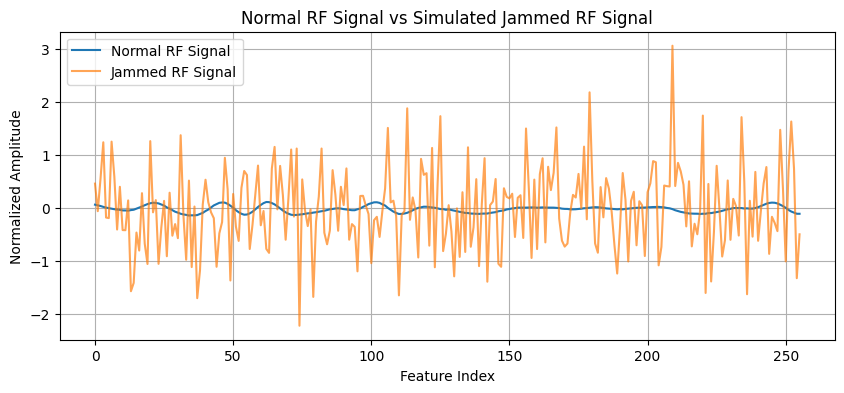

In [14]:
# -------------------------------
# Visualize normal and jammed signal
# -------------------------------

sample_index = 0

plt.figure(figsize=(10, 4))

plt.plot(X_normal_test[sample_index], label="Normal RF Signal")
plt.plot(X_jammed_anomaly[sample_index], label="Jammed RF Signal", alpha=0.7)

plt.title("Normal RF Signal vs Simulated Jammed RF Signal")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 21. Generate Reconstructed Outputs

The trained Autoencoder reconstructs:

1. Normal test signals
2. Jammed anomaly signals

The reconstructed output is generated by the model using learned weights and biases.

It is not manually calculated.

In [15]:
# -------------------------------
# Generate reconstructed outputs
# -------------------------------

# Reconstruct normal signals
normal_reconstructed = autoencoder.predict(X_normal_test)

# Reconstruct jammed anomaly signals
jammed_reconstructed = autoencoder.predict(X_jammed_anomaly)

print("Normal reconstructed shape:", normal_reconstructed.shape)
print("Jammed reconstructed shape:", jammed_reconstructed.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Normal reconstructed shape: (1000, 256)
Jammed reconstructed shape: (1000, 256)


## 22. Calculate Reconstruction Error

Reconstruction error is calculated using Mean Squared Error.

For each signal:

MSE = mean((Original Signal - Reconstructed Signal)²)

### Expected Behavior

Normal signals → Low reconstruction error  
Jammed signals → High reconstruction error

In [17]:
# -------------------------------
# Calculate reconstruction error
# -------------------------------

# Reconstruction error for normal test signals
normal_errors = np.mean((X_normal_test - normal_reconstructed) ** 2, axis=1)

# Reconstruction error for jammed anomaly signals
jammed_errors = np.mean((X_jammed_anomaly - jammed_reconstructed) ** 2, axis=1)

print("Normal reconstruction error:")
print("Mean:", np.mean(normal_errors))
print("Minimum:", np.min(normal_errors))
print("Maximum:", np.max(normal_errors))

print("\nJammed anomaly reconstruction error:")
print("Mean:", np.mean(jammed_errors))
print("Minimum:", np.min(jammed_errors))
print("Maximum:", np.max(jammed_errors))

Normal reconstruction error:
Mean: 0.0011759412
Minimum: 0.0002567721
Maximum: 0.0057388037

Jammed anomaly reconstruction error:
Mean: 0.6450162413097377
Minimum: 0.44979797575842734
Maximum: 0.882847987346884


## 23. Select Threshold

A threshold is needed to decide whether a signal is normal or anomalous.

Here, the threshold is selected using the 95th percentile of normal reconstruction errors.

This means most normal signals should have reconstruction error below the threshold.

### Decision Rule

Error ≤ Threshold → Normal  
Error > Threshold → Anomaly

In [18]:
# -------------------------------
# Select threshold
# -------------------------------

threshold = np.percentile(normal_errors, 95)

print("Selected threshold:", threshold)

Selected threshold: 0.0019392072


## 24. Predict Normal and Anomaly Signals

Now we classify signals using the threshold.

For each signal:

- If reconstruction error is greater than threshold, prediction = anomaly
- Otherwise, prediction = normal

In [19]:
# -------------------------------
# Make predictions using threshold
# -------------------------------

# False means Normal, True means Anomaly
normal_predictions = normal_errors > threshold
jammed_predictions = jammed_errors > threshold

# Count results
normal_wrong = np.sum(normal_predictions)
normal_correct = len(normal_errors) - normal_wrong

jammed_correct = np.sum(jammed_predictions)
jammed_wrong = len(jammed_errors) - jammed_correct

print("Threshold:", threshold)

print("\nNormal test samples:", len(normal_errors))
print("Normal correctly detected:", normal_correct)
print("Normal wrongly detected as anomaly:", normal_wrong)

print("\nJammed anomaly samples:", len(jammed_errors))
print("Jammed correctly detected as anomaly:", jammed_correct)
print("Jammed wrongly detected as normal:", jammed_wrong)

# Calculate accuracy
accuracy = (normal_correct + jammed_correct) / (len(normal_errors) + len(jammed_errors))

print("\nAnomaly Detection Accuracy:", accuracy)

Threshold: 0.0019392072

Normal test samples: 1000
Normal correctly detected: 950
Normal wrongly detected as anomaly: 50

Jammed anomaly samples: 1000
Jammed correctly detected as anomaly: 1000
Jammed wrongly detected as normal: 0

Anomaly Detection Accuracy: 0.975


## 
25. Confusion Matrix and Classification Report

The confusion matrix shows how many samples were correctly and incorrectly classified.

Labels:

- 0 = Normal
- 1 = Anomaly

The classification report shows:

- Precision
- Recall
- F1-score
- Accuracy

Final Accuracy: 0.975


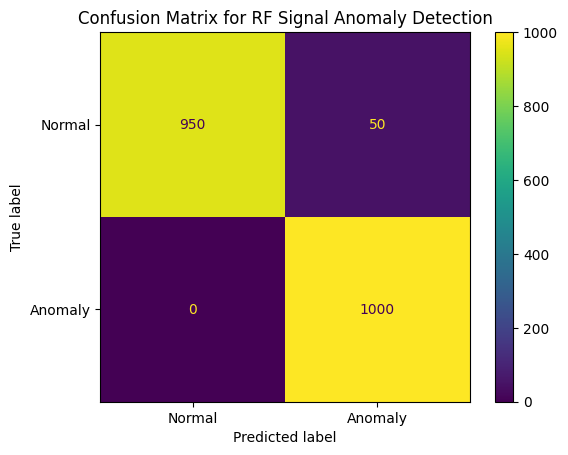

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      1000
     Anomaly       0.95      1.00      0.98      1000

    accuracy                           0.97      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.97      0.97      2000



In [20]:
# -------------------------------
# Confusion matrix and classification report
# -------------------------------

# True labels
# Normal signals are labeled 0
# Jammed anomaly signals are labeled 1
y_true = np.concatenate([
    np.zeros(len(normal_errors)),
    np.ones(len(jammed_errors))
])

# Predicted labels
y_pred = np.concatenate([
    normal_predictions.astype(int),
    jammed_predictions.astype(int)
])

# Accuracy score
final_accuracy = accuracy_score(y_true, y_pred)
print("Final Accuracy:", final_accuracy)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("Confusion Matrix for RF Signal Anomaly Detection")
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))

## 26. Reconstruction Error Histogram

This histogram shows the distribution of reconstruction errors.

Expected observation:

- Normal signals should have low reconstruction error.
- Jammed anomaly signals should have high reconstruction error.
- The threshold should separate normal and anomaly regions.

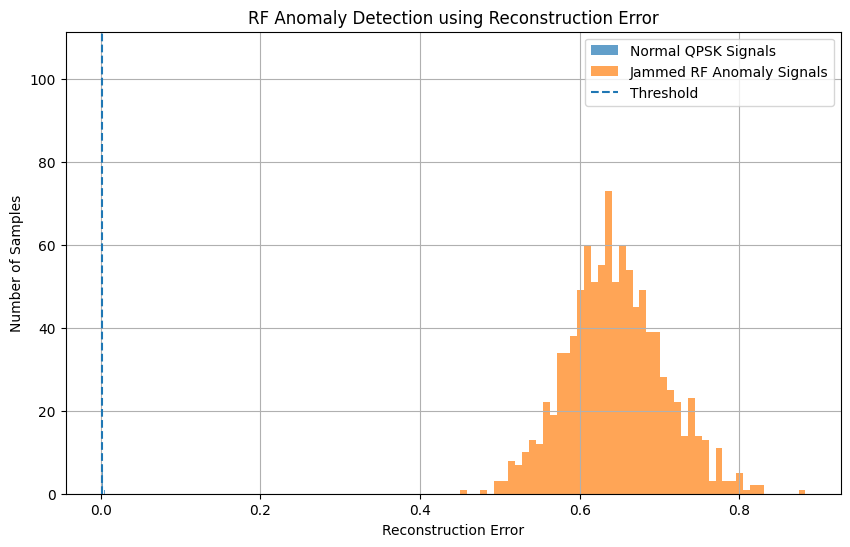

In [21]:
# -------------------------------
# Plot reconstruction error histogram
# -------------------------------

plt.figure(figsize=(10, 6))

plt.hist(normal_errors, bins=50, alpha=0.7, label="Normal QPSK Signals")
plt.hist(jammed_errors, bins=50, alpha=0.7, label="Jammed RF Anomaly Signals")

plt.axvline(threshold, linestyle="--", label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("RF Anomaly Detection using Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

## 27. Compare Original and Reconstructed Signal

This cell visualizes how the Autoencoder reconstructs one normal signal and one jammed signal.

For normal signals, reconstruction should be close to the original input.

For jammed signals, reconstruction may not match well because the model was trained only on normal signals.

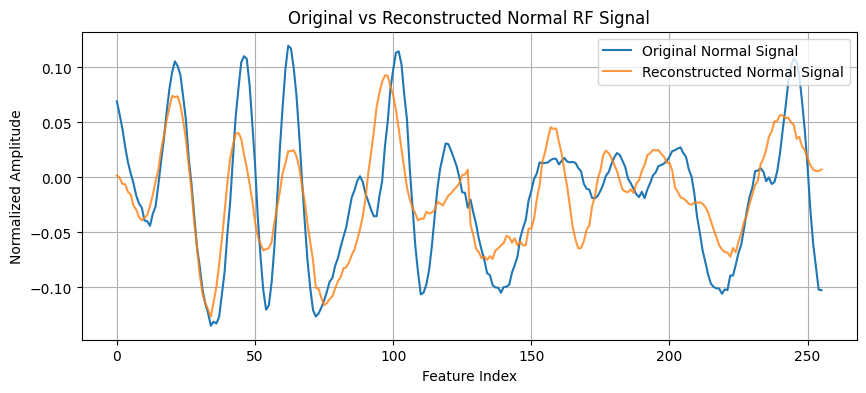

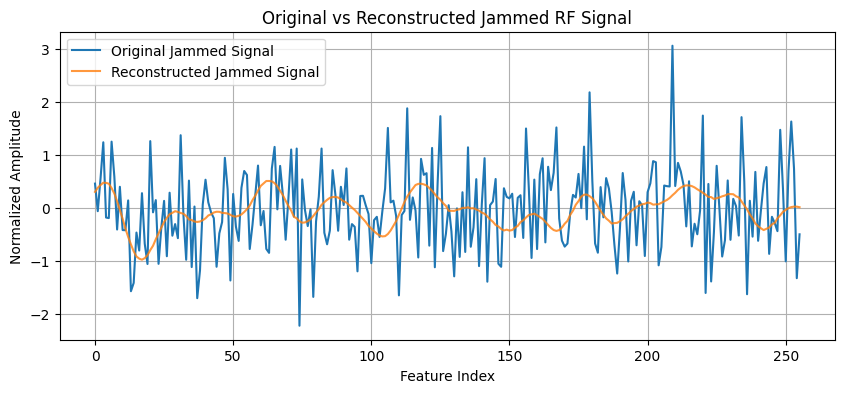

In [22]:
# -------------------------------
# Compare original and reconstructed signals
# -------------------------------

sample_index = 0

# Normal signal comparison
plt.figure(figsize=(10, 4))
plt.plot(X_normal_test[sample_index], label="Original Normal Signal")
plt.plot(normal_reconstructed[sample_index], label="Reconstructed Normal Signal", alpha=0.8)
plt.title("Original vs Reconstructed Normal RF Signal")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Jammed signal comparison
plt.figure(figsize=(10, 4))
plt.plot(X_jammed_anomaly[sample_index], label="Original Jammed Signal")
plt.plot(jammed_reconstructed[sample_index], label="Reconstructed Jammed Signal", alpha=0.8)
plt.title("Original vs Reconstructed Jammed RF Signal")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 28. View the Compressed Representation

The encoder compresses each RF signal from 256 features into 32 features.

This compressed representation is also called:

- Bottleneck representation
- Latent representation
- Compressed feature vector

It contains the important learned features of normal RF signals.

In [23]:
# -------------------------------
# Extract compressed representation from encoder
# -------------------------------

encoder_model = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("compressed_layer").output
)

compressed_features = encoder_model.predict(X_normal_test)

print("Original RF signal dimension:", X_normal_test.shape[1])
print("Compressed representation dimension:", compressed_features.shape[1])
print("Compressed feature shape:", compressed_features.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Original RF signal dimension: 256
Compressed representation dimension: 32
Compressed feature shape: (1000, 32)


## 29. Function to Predict a Single RF Signal

This function takes one RF signal as input and predicts whether it is normal or anomaly.

It follows the same logic:

1. Reconstruct the signal using the Autoencoder.
2. Calculate reconstruction error.
3. Compare with threshold.
4. Return Normal or Anomaly.

In [24]:
# -------------------------------
# Function to predict one signal
# -------------------------------

def predict_rf_signal(signal, model, threshold):
    # Predict whether a single RF signal is Normal or Anomaly.
    # signal should have shape (256,)
    # model should be the trained Autoencoder.
    # threshold is the reconstruction error threshold.

    # Reshape signal into batch format because model expects 2D input
    signal = signal.reshape(1, -1)

    # Generate reconstructed output
    reconstructed = model.predict(signal, verbose=0)

    # Calculate reconstruction error
    error = np.mean((signal - reconstructed) ** 2)

    # Apply threshold
    if error > threshold:
        result = "Anomaly"
    else:
        result = "Normal"

    return result, error


# Test with one normal signal
normal_result, normal_error = predict_rf_signal(X_normal_test[0], autoencoder, threshold)

# Test with one jammed signal
jammed_result, jammed_error = predict_rf_signal(X_jammed_anomaly[0], autoencoder, threshold)

print("Normal sample prediction:", normal_result)
print("Normal sample reconstruction error:", normal_error)

print("\nJammed sample prediction:", jammed_result)
print("Jammed sample reconstruction error:", jammed_error)

Normal sample prediction: Normal
Normal sample reconstruction error: 0.0015701023

Jammed sample prediction: Anomaly
Jammed sample reconstruction error: 0.6155656624866541


## 30. Final Conclusion

In this project, a Deep Autoencoder was used for RF signal anomaly detection.

The model was trained only on normal QPSK RF signals.  
After training, normal signals produced low reconstruction error.

Jammed RF signals were simulated by adding strong random noise.  
These jammed signals produced high reconstruction error.

A threshold was selected using the 95th percentile of normal reconstruction errors.

Signals with reconstruction error greater than the threshold were classified as anomalies.

This shows that Autoencoder-based reconstruction error can be used to detect abnormal RF signal behavior.